In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

# Setup

In [3]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm
from shapely import MultiPolygon

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [5]:
from gridsample.utils import create_ids, save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [6]:
def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(math.ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    
    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a,i] *= np.linspace(0.2, 1, a)
    ret[a:,3] *= np.linspace(1, 0.3, b)
    
    return ret[:N]  # Return only the requested number of colors

In [7]:
def clean_geometry(gdf):
    """Clean geometry collections and multipolygons by keeping only polygon geometries."""
    def _clean_geom(geom):
        if geom is None:
            return None
        
        # If it's already a Polygon, return as is
        if geom.geom_type == 'Polygon':
            return geom

        # Get polygons from MultiPolygon or GeometryCollection 
        polygons = []
        if hasattr(geom, 'geoms'):
            for g in geom.geoms:
                if g.geom_type == 'Polygon':
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return None
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and drop invalid geometries
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf.dropna(subset=['geometry'])

In [8]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
CLEANED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels" / "v5"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

# 0. Load cleaned khasras

In [9]:
LOCATION = "Shivpuri"
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / LOCATION / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
shivpuri_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "shivpuri_cleaned_khasras.parquet")
shivpuri_gdf

,geometry,FID,Area_ha,Patch_Name,districtc,tehsilcode,villageh,village_name,bhucode,khasra_no,...,ownername,column12in,noiyat,landtype,GIS_Area_h,teh_nm_e,ccode11,lgd_gp_cd,khasra_id,Cluster
0,"MULTIPOLYGON (((78.23840 25.14023, 78.23810 25...",0,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2831,...,(शासकीय),,चारागाह 1.0000,शासकीय,1.033963,Pichhore,456248,151450,050603001001742831,Cluster8
1,"MULTIPOLYGON (((78.24014 25.14096, 78.23970 25...",1,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2832,...,(शासकीय),,चारागाह 3.5900,शासकीय,3.702107,Pichhore,456248,151450,050603001001742832,Cluster8
2,"MULTIPOLYGON (((78.24106 25.14042, 78.24111 25...",2,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2833,...,(शासकीय),,चारागाह 0.2300,शासकीय,0.248963,Pichhore,456248,151450,050603001001742833,Cluster8
3,"MULTIPOLYGON (((78.23943 25.13843, 78.23933 25...",3,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2836,...,(शासकीय),,चारागाह 0.9000,शासकीय,0.873786,Pichhore,456248,151450,050603001001742836,Cluster8
4,"MULTIPOLYGON (((78.23916 25.13742, 78.23912 25...",4,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2837,...,(शासकीय),,बंघीया 1.0500,शासकीय,0.038632,Pichhore,456248,151450,050603001001742837,Cluster8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,"MULTIPOLYGON (((77.47755 25.81260, 77.47613 25...",970,79.488672,SVPI_176,423,01009,ठेवला,Thewala,05090100002005,1154/2,...,(शासकीय),,0.8000पठार 0.8000 0.8000,शासकीय,0.90143,Bairrad,454991,151812,050901000020051154/2,Cluster2
971,"MULTIPOLYGON (((77.47682 25.81431, 77.47701 25...",971,79.488672,SVPI_176,423,01009,ठेवला,Thewala,05090100002005,1149/2,...,(शासकीय),,5.0000 5.0000 5.0000,शासकीय,1.768495,Bairrad,454991,151812,050901000020051149/2,Cluster2
972,"MULTIPOLYGON (((78.23841 25.13607, 78.23830 25...",972,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2855,...,(शासकीय),,पठार 0.1500,शासकीय,0.161368,Pichhore,456248,151450,050603001001742855,Cluster8
973,"MULTIPOLYGON (((78.23881 25.13629, 78.23886 25...",973,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2856,...,(शासकीय),,पठार 0.0400,शासकीय,0.055191,Pichhore,456248,151450,050603001001742856,Cluster8


In [11]:
# use Cluster as parcel_cluster_id and Patch_Name as parcel_id
gdf_with_parcel_cluster_id = shivpuri_gdf.rename(
    columns={"Cluster": "parcel_cluster_id", "Patch_Name": "parcel_id"}
)

In [12]:
gdf_with_parcel_cluster_id = gdf_with_parcel_cluster_id.to_crs(INDIA_PROJECTED_CRS).reset_index(
    drop=True
)[["geometry", "khasra_no", "khasra_id", "village_name", "parcel_id", "parcel_cluster_id"]]

In [13]:
gdf_with_parcel_cluster_id["Khasra Area (ha)"] = gdf_with_parcel_cluster_id.area / 10_000

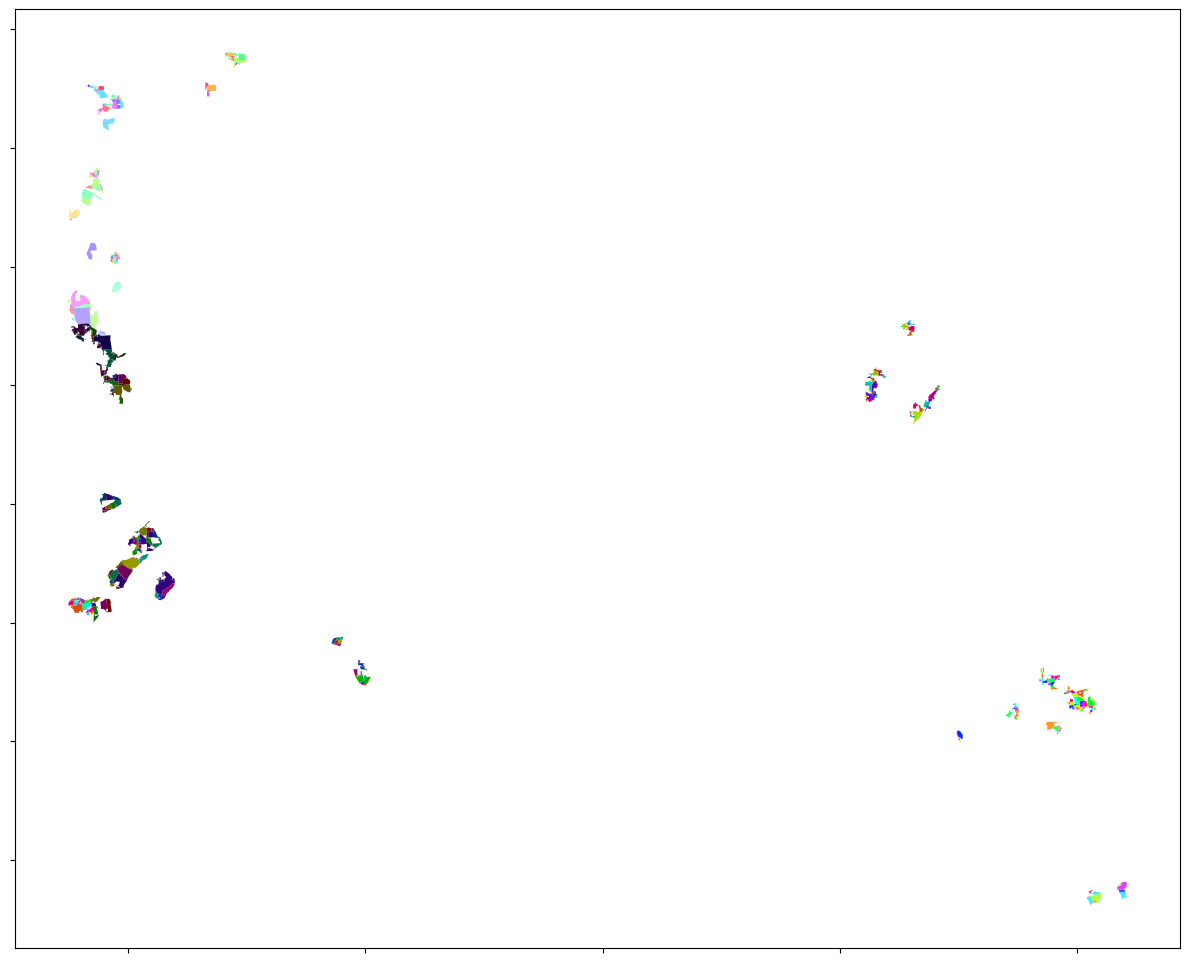

In [14]:
ax = gdf_with_parcel_cluster_id.plot(
    column="khasra_id",
    cmap=ListedColormap(generate_colormap(len(gdf_with_parcel_cluster_id))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

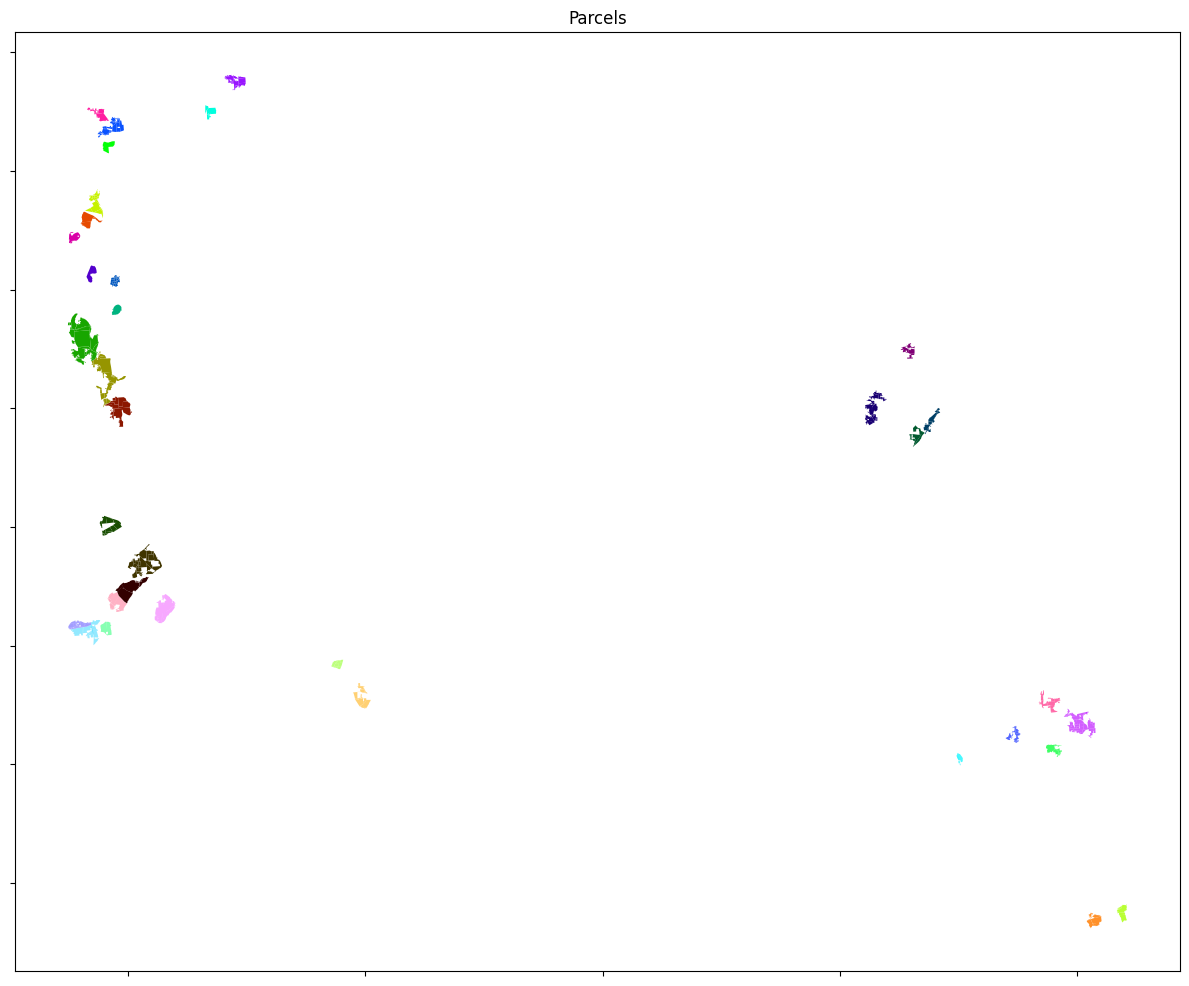

In [15]:
ax = gdf_with_parcel_cluster_id.plot(
    column="parcel_id",
    cmap=ListedColormap(generate_colormap(len(gdf_with_parcel_cluster_id["parcel_id"].unique()))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.title("Parcels")
plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "parcel_initial.png",
    dpi=300,
    bbox_inches="tight",
)

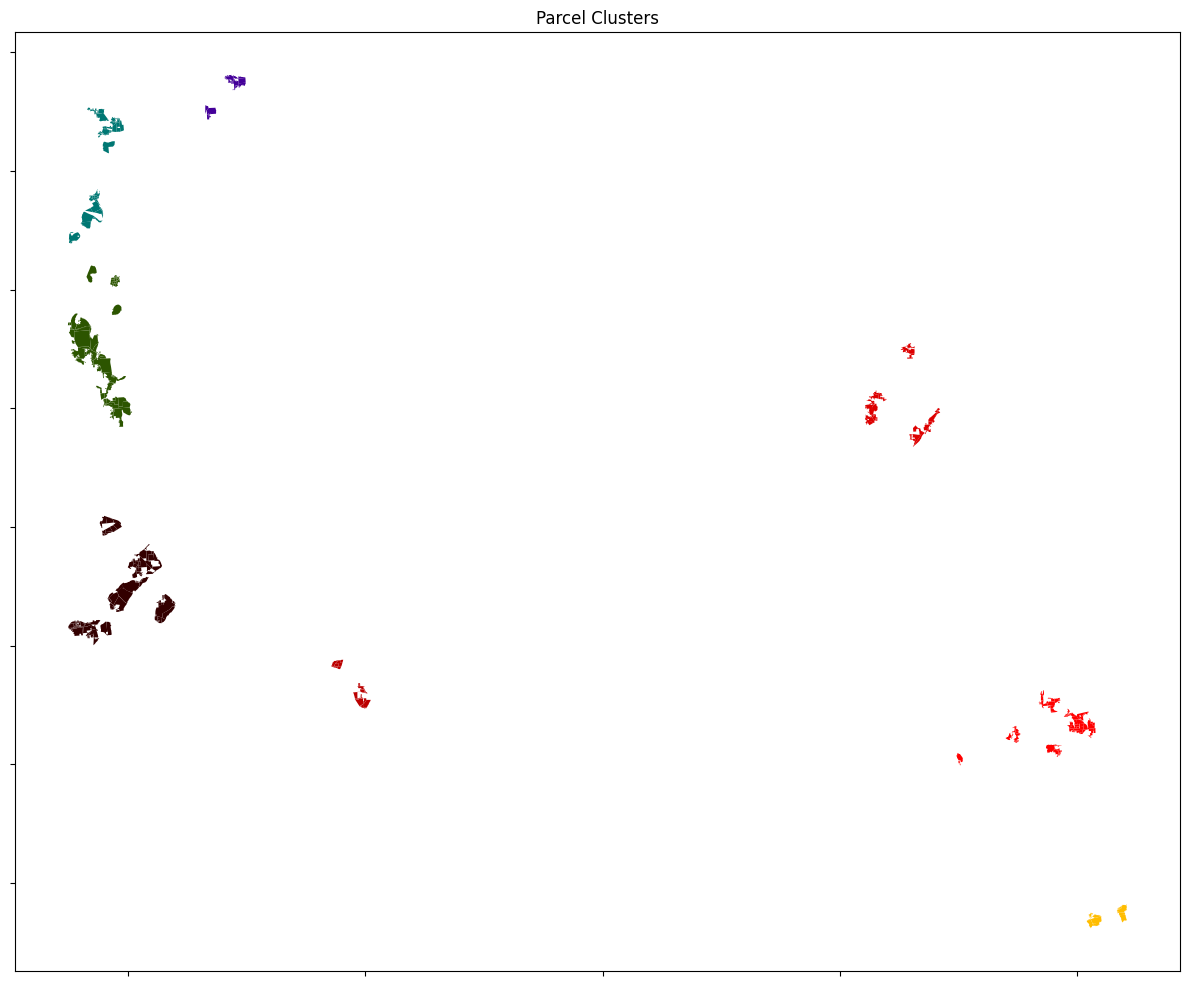

In [16]:
ax = gdf_with_parcel_cluster_id.plot(
    column="parcel_cluster_id",
    cmap=ListedColormap(generate_colormap(len(gdf_with_parcel_cluster_id["parcel_cluster_id"].unique()))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.title("Parcel Clusters")
plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "parcel_clusters_initial.png",
    dpi=300,
    bbox_inches="tight",
)

### Make parcel-level gdf

In [30]:
gdf_with_parcel_cluster_id

,geometry,khasra_no,khasra_id,village_name,parcel_id,parcel_cluster_id,Khasra Area (ha)
0,"MULTIPOLYGON (((3781038.762 147387.639, 378100...",2831,050603001001742831,Kamalpur,SVPI_18,Cluster8,1.049292
1,"MULTIPOLYGON (((3781206.536 147485.325, 378116...",2832,050603001001742832,Kamalpur,SVPI_18,Cluster8,3.756991
2,"MULTIPOLYGON (((3781305.521 147434.246, 378130...",2833,050603001001742833,Kamalpur,SVPI_18,Cluster8,0.252653
3,"MULTIPOLYGON (((3781162.161 147197.610, 378115...",2836,050603001001742836,Kamalpur,SVPI_18,Cluster8,0.886747
4,"MULTIPOLYGON (((3781145.824 147083.171, 378114...",2837,050603001001742837,Kamalpur,SVPI_18,Cluster8,0.039205
...,...,...,...,...,...,...,...
970,"MULTIPOLYGON (((3697472.517 214901.277, 369732...",1154/2,050901000020051154/2,Thewala,SVPI_176,Cluster2,0.912070
971,"MULTIPOLYGON (((3697382.575 215084.423, 369738...",1149/2,050901000020051149/2,Thewala,SVPI_176,Cluster2,1.789349
972,"MULTIPOLYGON (((3781084.639 146925.671, 378107...",2855,050603001001742855,Kamalpur,SVPI_18,Cluster8,0.163763
973,"MULTIPOLYGON (((3781122.308 146953.539, 378112...",2856,050603001001742856,Kamalpur,SVPI_18,Cluster8,0.056010


In [32]:
cluster_7_areas = gdf_with_parcel_cluster_id[gdf_with_parcel_cluster_id["parcel_cluster_id"] == "Cluster7"].groupby("parcel_id")["Khasra Area (ha)"].sum()

In [35]:
cluster_7_areas.round(2)

parcel_id
SVPI_41     69.73
SVPI_42     28.05
SVPI_45     55.83
SVPI_46    261.26
SVPI_47    102.16
Name: Khasra Area (ha), dtype: float64

In [17]:
from utils import get_closest_parcels

In [18]:
parcel_gdf = gdf_with_parcel_cluster_id.dissolve(by="parcel_cluster_id")
parcel_gdf = parcel_gdf.drop(columns=["khasra_id", "khasra_no", "parcel_id", "Khasra Area (ha)"])
parcel_gdf = parcel_gdf.reset_index()

In [19]:
parcel_gdf.loc[:, "Original Parcel Area (ha)"] = parcel_gdf["geometry"].area / 10_000

In [20]:
parcel_gdf

,parcel_cluster_id,geometry,village_name,Original Parcel Area (ha)
0,Cluster0,"MULTIPOLYGON (((3695444.029 171406.187, 369547...",Sarjapur,1440.345324
1,Cluster1,"MULTIPOLYGON (((3696422.376 193854.572, 369640...",Jhalwasa,1350.887335
2,Cluster2,"MULTIPOLYGON (((3695153.100 203909.210, 369513...",Bairad,579.206563
3,Cluster3,"MULTIPOLYGON (((3706855.119 214486.747, 370685...",Kishanpura,170.121805
4,Cluster4,"MULTIPOLYGON (((3719575.511 164914.686, 371957...",Badagaon,166.813965
5,Cluster6,"MULTIPOLYGON (((3762638.194 188660.137, 376262...",Jerawa,398.157050
6,Cluster7,"MULTIPOLYGON (((3770108.683 159907.842, 377010...",Kachhaua,513.124985
7,Cluster8,"MULTIPOLYGON (((3781121.137 146277.748, 378111...",Kamalpur,162.659235


In [21]:
# add how many khasras are inside
khasra_counts_series = gdf_with_parcel_cluster_id.groupby("parcel_cluster_id")["khasra_id"].count()
parcel_gdf["Total Khasra Count"] = parcel_gdf["parcel_cluster_id"].map(khasra_counts_series)

# add the names of all khasras that fall inside each parcel as a list under khasra_ids
khasra_ids_series = gdf_with_parcel_cluster_id.groupby("parcel_cluster_id")["khasra_no"].apply(list).astype(str)
parcel_gdf["All Khasra IDs"] = parcel_gdf["parcel_cluster_id"].map(khasra_ids_series).astype(str)

In [22]:
# add how many parcels are inside
parcel_counts_series = (
    gdf_with_parcel_cluster_id.groupby("parcel_cluster_id")["parcel_id"]
    .apply(set)
    .apply(len)
)
parcel_gdf["Total Parcel Count"] = parcel_gdf["parcel_cluster_id"].map(parcel_counts_series)

# add the names of all patches that fall inside each parcel as a list under patch_ids
parcel_ids_series = (
    gdf_with_parcel_cluster_id.groupby("parcel_cluster_id")["parcel_id"]
    .apply(set)
    .apply(list)
    .astype(str)
)
parcel_gdf["All Parcel IDs"] = parcel_gdf["parcel_cluster_id"].map(parcel_ids_series).astype(str)

In [23]:
# Calculate minimum distances and closest parcel_cluster_ids
min_distances, closest_ids = get_closest_parcels(parcel_gdf, parcel_id_col="parcel_cluster_id")

# Add the results as new columns
parcel_gdf.loc[:, "Closest Parcel Cluster Distance (m)"] = min_distances
parcel_gdf.loc[:, "Closest Parcel Cluster ID"] = closest_ids

In [24]:
# Distance from central parcel
source_parcel_cluster_id = "Cluster4"
source_geom = parcel_gdf[parcel_gdf["parcel_cluster_id"] == source_parcel_cluster_id]
distances_to_source = parcel_gdf.geometry.apply(lambda x: source_geom.distance(x))

distances_to_source.columns = [f"Distance to {source_parcel_cluster_id} (m)"]
parcel_gdf = parcel_gdf.merge(
    distances_to_source, left_index=True, right_index=True
)

In [25]:
parcel_gdf

,parcel_cluster_id,geometry,village_name,Original Parcel Area (ha),Total Khasra Count,All Khasra IDs,Total Parcel Count,All Parcel IDs,Closest Parcel Cluster Distance (m),Closest Parcel Cluster ID,Distance to Cluster4 (m)
0,Cluster0,"MULTIPOLYGON (((3695444.029 171406.187, 369547...",Sarjapur,1440.345324,214,"['76', '172', '3/2', '4', '5', '7', '12', '13'...",8,"['SVPI_100', 'SVPI_99', 'SVPI_112', 'SVPI_86',...",7601.55,Cluster1,14025.981242
1,Cluster1,"MULTIPOLYGON (((3696422.376 193854.572, 369640...",Jhalwasa,1350.887335,228,"['1151', '1152', '1252', '1253', '1255', '1256...",6,"['SVPI_133', 'SVPI_122', 'SVPI_140', 'SVPI_126...",2395.09,Cluster2,26558.640024
2,Cluster2,"MULTIPOLYGON (((3695153.100 203909.210, 369513...",Bairad,579.206563,120,"['2427', '2077', '2108', '2109', '2820', '2757...",6,"['SVPI_165', 'SVPI_150', 'SVPI_149', 'SVPI_176...",2395.09,Cluster1,41484.884803
3,Cluster3,"MULTIPOLYGON (((3706855.119 214486.747, 370685...",Kishanpura,170.121805,77,"['11', '40', '45', '46', '47', '48', '6/2', '1...",2,"['SVPI_162', 'SVPI_169']",6938.34,Cluster2,46818.663873
4,Cluster4,"MULTIPOLYGON (((3719575.511 164914.686, 371957...",Badagaon,166.813965,34,"['10', '11', '12', '17', '648', '649', '672', ...",2,"['SVPI_57', 'SVPI_68']",14025.98,Cluster0,0.000000
5,Cluster6,"MULTIPOLYGON (((3762638.194 188660.137, 376262...",Jerawa,398.157050,85,"['1', '188', '31', '41', '42', '48', '54', '68...",4,"['SVPI_113', 'SVPI_114', 'SVPI_116', 'SVPI_120']",23236.32,Cluster7,47646.137951
6,Cluster7,"MULTIPOLYGON (((3770108.683 159907.842, 377010...",Kachhaua,513.124985,186,"['293', '294', '299', '300', '301', '305', '30...",5,"['SVPI_46', 'SVPI_47', 'SVPI_42', 'SVPI_41', '...",13427.86,Cluster8,49548.559591
7,Cluster8,"MULTIPOLYGON (((3781121.137 146277.748, 378111...",Kamalpur,162.659235,31,"['2831', '2832', '2833', '2836', '2837', '2840...",2,"['SVPI_18', 'SVPI_20']",13427.86,Cluster7,63107.409344


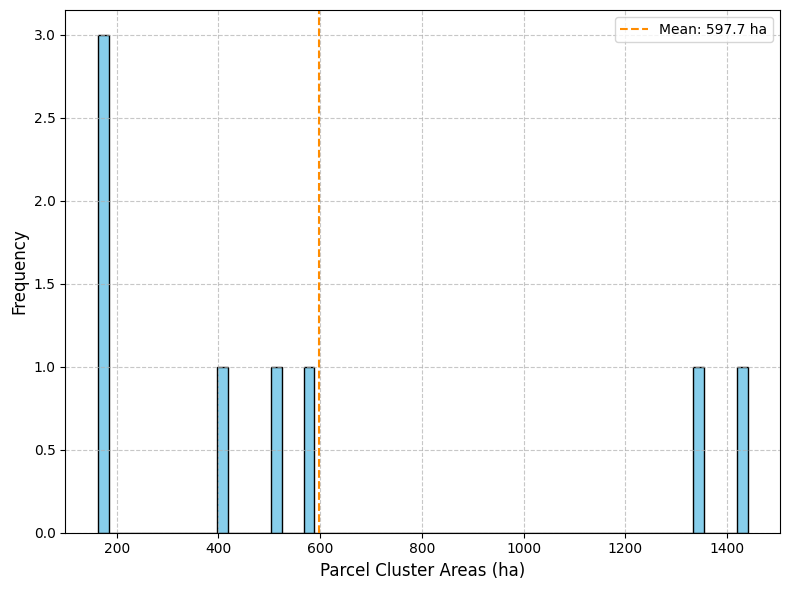

In [26]:
# Plotting the histogram of intra-distances
f, ax = plt.subplots(1, 1, figsize=(8, 6))
parcel_gdf["Original Parcel Area (ha)"].hist(
    ax=ax, bins=60, color="skyblue", edgecolor="black"
)

# # add lines for percentile
# percentile_area = round(parcel_gdf["Original Parcel Area (ha)"].quantile(0.75), 1)
# ax.axvline(
#     percentile_area,
#     color="darkgreen",
#     linestyle="--",
#     label=f"75th Percentile: {percentile_area} ha",
# )

# add line for average
mean_area = round(parcel_gdf["Original Parcel Area (ha)"].mean(), 1)
ax.axvline(
    mean_area,
    color="darkorange",
    linestyle="--",
    label=f"Mean: {mean_area} ha",
)

ax.legend()
# ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
ax.set_xlabel("Parcel Cluster Areas (ha)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR
    / "parcel_clusters_initial_area_histogram.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [27]:
save_shapefiles(
    parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcel_clusters_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [ ]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3

#### Download rooftop data
Get the ID of the level 6 S2 Cell that this area sits inside

In [ ]:
s2_ids = []

for index, row in parcel_gdf.to_crs(4326).iterrows():
    lat = row["geometry"].centroid.y
    lon = row["geometry"].centroid.x
    s2_cell_id = lat_lon_to_cell_id(lat=lat, lon=lon, level=6)
        
    s2_ids.append(s2_cell_id)

s2_ids = list(set(s2_ids))


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [ ]:
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print("File already exists")
    else:
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        s3.download_file(
            "vida",
            f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
            str(s2_rooftops_path),
        )
        print("File downloaded.")

#### Load and process rooftop data

In [ ]:
rooftop_gdf_list = []
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
rooftop_gdf = rooftop_gdf[
    [
        "bf_source",
        "confidence",
        "area_in_meters",
        "geometry",
    ]
]

rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

#### Filter to only rooftops that overlap the parcels

In [ ]:
subset_rooftops_gdf = rooftop_gdf.sjoin(
    parcel_gdf, how="inner", predicate="intersects"
).drop(columns=["index_right"])
subset_rooftops_gdf.drop(
    columns=parcel_gdf.columns.drop("geometry"), inplace=True
)

In [ ]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, parcel_gdf, how="intersection"
)

#### Settlements - auto or manual

In [ ]:
# AUTOMATIC
from sklearn.cluster import DBSCAN

for eps in [200, 250, 300]:
    clusterer = DBSCAN(eps=eps, min_samples=3, n_jobs=-1)
    building_centroids = buildings_overlap_gdf.geometry.centroid
    X = np.array(list(zip(building_centroids.x, building_centroids.y)))
    building_cluster_ids = clusterer.fit_predict(X)
    buildings_overlap_gdf["settlement_id"] = building_cluster_ids

    settlement_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] != -1
    ]
    rogue_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] == -1
    ]

    # get the convex hull of each cluster
    settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
    settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
    settlements_gdf.geometry = settlements_gdf.convex_hull

    # get cutout of the buffered building shapes that overlap parcels
    settlements_gdf = gpd.overlay(settlements_gdf, parcel_gdf, how="intersection")
    settlements_gdf = settlements_gdf[["parcel_cluster_id", "settlement_id", "geometry"]]

    # plot
    ax = parcel_gdf.plot(figsize=(20, 20))
    settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
    settlement_buildings_gdf.plot(ax=ax, color="red")
    rogue_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

    # add stats
    total_count = len(buildings_overlap_gdf)
    settlement_count = len(settlement_buildings_gdf)
    perc_settlement_buildings = settlement_count / total_count * 100
    rogue_count = len(rogue_buildings_gdf)
    total_area = buildings_overlap_gdf.area.sum() / 10_000
    settlement_area = settlements_gdf.area.sum() / 10_000
    title = f"""
    Buildings at {eps}m eps
    Total Buildings: {total_count}
    Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
    Total Building Area (ha): {total_area:.2f}
    Settlement Area (ha): {settlement_area:.2f}
    """
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    plt.savefig(
        DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
    )

In [ ]:
CHOSEN_EPS = 300
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=3, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)
buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, parcel_gdf, how="intersection")
settlements_gdf = settlements_gdf[["parcel_cluster_id", "settlement_id", "geometry"]]

In [ ]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(by="parcel_cluster_id").reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(by="parcel_cluster_id").reset_index()

In [ ]:
rogue_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = rogue_buildings_overlap_gdf.area / 10_000
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[["parcel_cluster_id", "Unavailable Area - Isolated Buildings (ha)"]]

In [ ]:
settlements_overlap_gdf = settlements_gdf.dissolve(by="parcel_cluster_id").reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = settlements_overlap_gdf.area / 10_000
settlements_unusable_area_df = settlements_overlap_gdf[["parcel_cluster_id", "Unusable Area - Settlements (ha)"]]

### Landcover (Cropland, Water)

#### Landcover

In [ ]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [ ]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [ ]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

In [ ]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [parcel_gdf.to_crs(4326).unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [ ]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [ ]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, parcel_gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="parcel_cluster_id").reset_index()

In [ ]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["parcel_cluster_id", "Unavailable Area - Cropland (ha)"]]

#### Water

In [ ]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_shapes_gdf, parcel_gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="parcel_cluster_id").reset_index()

In [ ]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["parcel_cluster_id", "Unusable Area - Water (ha)"]]

#### Trees

In [ ]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(
    tree_shapes_gdf, parcel_gdf, how="intersection"
)
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="parcel_cluster_id").reset_index()

In [ ]:
tree_overlap_gdf.plot()

In [ ]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[["parcel_cluster_id", "Unusable Area - Tree Cover (ha)"]]
tree_unusable_area_df

### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [ ]:
from pydem.dem_processing import DEMProcessor

In [ ]:
import xdem

In [ ]:
def get_steep_shapes(dem_filename):
    print(f"Processing {dem_filename}...")
    dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_proc = DEMProcessor(dem_filepath)
    transform = dem_proc.transform  # need this transform later

    # # calculate slope and aspect and save to file
    # slope_pydem, aspect_pydem = dem_proc.calc_slopes_directions()
    # np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", slope_pydem)
    # np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect_pydem)

    # OR if precomputed, load files
    slope_pydem = np.load(RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy")
    aspect_pydem = np.load(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy")

    # convert from radians to degrees
    aspect = np.degrees(aspect_pydem)
    slope = np.degrees(slope_pydem)

    # Display slope and aspect
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    # slope vis
    ax1.imshow(slope)
    ax1.set_title(f"{dem_filename} - Slope")
    ax2.hist(slope.flatten(), bins=100)
    ax2.set_title("Slope Histogram")
    # aspect vis
    ax3.imshow(aspect)
    ax3.set_title(f"{dem_filename} - Aspect")
    ax4.hist(aspect.flatten(), bins=100)
    ax4.set_title("Aspect Histogram")
    plt.tight_layout()
    plt.show()

    # set all values below 0 to 0
    aspect[aspect < 0] = 0
    slope[slope < 0] = 0

    # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
    slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

    # Plot the mask with a binary colormap and correct axes
    x_min = transform[2]
    x_max = x_min + transform[0] * slope_mask.shape[1]
    y_max = transform[5]
    y_min = y_max + transform[4] * slope_mask.shape[0]
    plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
    plt.colorbar(label="Aspect Mask", ax=ax)
    plt.title("Aspect Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    # Extract vector shapes and make a GeoDataFrame
    print("Extracting vector shapes...")
    vector_shapes = [
        {"geometry": shape(geom)}
        for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
    ]
    slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
    slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

    return slope_shapes_gdf

In [ ]:
dem_filenames = ["P5_PAN_CD_N25_000_E077_000_DEM_30m", "P5_PAN_CD_N25_000_E078_000_DEM_30m"]

steep_shapes_gdf_list = []
for dem_filename in dem_filenames:
    steep_shapes_gdf = get_steep_shapes(dem_filename)
    steep_shapes_gdf_list.append(steep_shapes_gdf)

In [ ]:
slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

In [ ]:
slope_overlap_gdf = gpd.overlay(
    slope_shapes_gdf, parcel_gdf, how="intersection", keep_geom_type=False
)
slope_overlap_gdf = slope_overlap_gdf.dissolve(by="parcel_cluster_id").reset_index()

In [ ]:
ax = parcel_gdf.plot(color="lightgrey")
slope_overlap_gdf.plot(ax=ax, column="parcel_cluster_id", color="red")

In [ ]:
slope_overlap_gdf["Unavailable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["parcel_cluster_id", "Unavailable Area - Slope (ha)"]]

## Merge in unusable layers
to find out which should be discarded and which taken forward

In [ ]:
parcel_gdf_for_unusable_area = parcel_gdf.copy()
selected_parcel_cluster_id_list = parcel_gdf_for_unusable_area["parcel_cluster_id"].unique()
selected_foldername = "Layered"

#### Plots

In [ ]:
FOLDER_PATH = OUTPUT_DATA_DIR / LOCATION
FOLDER_PATH.mkdir(parents=True, exist_ok=True)

# add colored outline based on parcel_cluster_id

ax = parcel_gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
parcel_gdf_for_unusable_area.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Parcel",
)
boundary_gdf = gpd.GeoDataFrame(
    parcel_gdf_for_unusable_area.convex_hull.boundary, columns=["geometry"]
)
boundary_gdf["parcel_cluster_id"] = parcel_gdf_for_unusable_area["parcel_cluster_id"]
boundary_gdf.plot(
    ax=ax,
    column="parcel_cluster_id",
    linewidth=0.5,
    cmap=ListedColormap(
        generate_colormap(len(parcel_gdf_for_unusable_area["parcel_cluster_id"].unique()))
    ),
    legend=True,
    legend_kwds={"loc": "upper right"},
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")

water_overlap_gdf[water_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list)].plot(
    ax=ax, color=WATER_COLOR, label="Water"
)

cropland_overlap_gdf[
    cropland_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

slope_overlap_gdf[slope_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list)].plot(
    ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
)

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "clusters_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
### THIS HAS THE MOST UPDATED PLOTTING CODE - 2nd April 2025
import matplotlib.patches as mpatches

for CHOSEN_PARCEL_ID in selected_parcel_cluster_id_list:
    FOLDER_PATH = (
        OUTPUT_DATA_DIR
        / LOCATION
        / "Individual Parcels"
        / selected_foldername
        / CHOSEN_PARCEL_ID
    )
    FOLDER_PATH.mkdir(parents=True, exist_ok=True)

    # # 1. Histogram of intra-distances
    # subset_intra_distances_df = intra_distances_df[
    #     intra_distances_df["parcel_cluster_id"] == CHOSEN_PARCEL_ID
    # ]

    # f, ax = plt.subplots(1, 1, figsize=(8, 6))
    # subset_intra_distances_df["raw_distances"].hist(
    #     ax=ax, bins=25, color="skyblue", edgecolor="black"
    # )

    # # add lines for average and 75% percentile
    # avg_distance = subset_intra_distances_df[
    #     "Inter-Khasra Distance Average (m)"
    # ].values[0]
    # percentile_75th_distance = subset_intra_distances_df[
    #     "Inter-Khasra Distance 75th Percentile (m)"
    # ].values[0]

    # ax.axvline(
    #     avg_distance,
    #     color=BACKGROUND_COLOR,
    #     linestyle="--",
    #     label=f"Average: {avg_distance}m",
    # )
    # ax.axvline(
    #     percentile_75th_distance,
    #     color="darkgreen",
    #     linestyle="--",
    #     label=f"75th Percentile: {percentile_75th_distance}m",
    # )

    # ax.legend()
    # # ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
    # ax.set_xlabel("Distance to Neighbouring Khasra", fontsize=12)
    # ax.set_ylabel("Frequency", fontsize=12)
    # ax.grid(True, linestyle="--", alpha=0.7)

    # plt.tight_layout()
    # plt.savefig(
    #     FOLDER_PATH / "intra_distances_histogram.png", dpi=300, bbox_inches="tight"
    # )
    # plt.show()

    # 2. Khasra-level plot
    ax = gdf_with_parcel_cluster_id[gdf_with_parcel_cluster_id["parcel_cluster_id"] == CHOSEN_PARCEL_ID].plot(
        column="khasra_id",
        cmap=ListedColormap(
            generate_colormap(len(gdf_with_parcel_cluster_id["khasra_id"].unique()))
        ),
        figsize=(8, 8),
    )

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # add a 1km line to show scale on the plot
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.plot(
        [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
    )
    ax.plot(
        [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
    )
    ax.plot(
        [xmax - 550, xmax - 450],
        [ymin + 50, ymin + 50],
        color="white",
        linewidth=7,
        linestyle="-",
    )
    ax.text(xmax - 500, ymin + 50, "1km", fontsize=6, ha="center")

    plt.tight_layout()
    plt.savefig(FOLDER_PATH / "khasras.png", dpi=300, bbox_inches="tight")

    # 3. Parcel + Layers plots

    handles = []
    for i in range(5):
        ax = gdf_with_parcel_cluster_id[
            gdf_with_parcel_cluster_id["parcel_cluster_id"] == CHOSEN_PARCEL_ID
        ].plot(
            color=BACKGROUND_COLOR,
            label="Original Parcel",
            figsize=(11, 11),
        )
        handles.append(
            mpatches.Patch(
                color=BACKGROUND_COLOR,
                label="Usable and Available Area",
            )
        )
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_title(f"{CHOSEN_PARCEL_ID}", fontsize=24)
        # add a 1km line to show scale on the plot
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        ax.plot(
            [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
        )
        ax.plot(
            [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
        )
        ax.plot(
            [xmax - 550, xmax - 450],
            [ymin + 30, ymin + 30],
            color="white",
            linewidth=7,
            linestyle="-",
        )
        ax.text(xmax - 500, ymin + 30, "1km", fontsize=12, ha="center")

        # add buildings as first layer
        buildings_overlap_gdf[
            buildings_overlap_gdf["parcel_cluster_id"] == CHOSEN_PARCEL_ID
        ].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")
        LAYERS = "Buildings"
        handles.append(
            mpatches.Patch(color=BUILDING_COLOR, label="Buildings + 25m buffer")
        )

        if i >= 1:
            settlements_overlap_gdf[
                settlements_overlap_gdf["parcel_cluster_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")
            LAYERS = "Buildings, Settlements"
            handles.append(mpatches.Patch(color=SETTLEMENT_COLOR, label="Settlements"))

        if i >= 2:
            water_overlap_gdf[water_overlap_gdf["parcel_cluster_id"] == CHOSEN_PARCEL_ID].plot(
                ax=ax, color=WATER_COLOR, label="Water"
            )
            LAYERS = "Buildings, Settlements, Water"
            handles.append(mpatches.Patch(color=WATER_COLOR, label="Water"))

        if i >= 3:
            cropland_overlap_gdf[
                cropland_overlap_gdf["parcel_cluster_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")
            LAYERS = "Buildings, Settlements, Water, Cropland"
            handles.append(mpatches.Patch(color=CROPLAND_COLOR, label="Cropland"))

        if i >= 4:
            slope_overlap_gdf[slope_overlap_gdf["parcel_cluster_id"] == CHOSEN_PARCEL_ID].plot(
                ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
            )
            LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
            handles.append(
                mpatches.Patch(color=SLOPE_COLOR, label="Slope > 7° between NE and NW")
            )

        ax.legend(handles=handles, loc="upper left")
        plt.tight_layout()
        plt.savefig(
            FOLDER_PATH / f"Layers - {LAYERS}.png", dpi=300, bbox_inches="tight"
        )
        handles = []

#### Calculate Areas

##### Cut out unusable

In [ ]:
output_parcel_gdf = parcel_gdf_for_unusable_area.copy()

# cut out water
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    water_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out settlements
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    settlements_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [ ]:
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [ ]:
# make usable area var so we can put unusable columns first, then usable ones
usable_area_series = output_parcel_gdf.area / 10_000
# unusable area
output_parcel_gdf["Unusable Area (ha)"] = (
    output_parcel_gdf["Original Parcel Area (ha)"] - usable_area_series
)
# usable area
output_parcel_gdf["Usable Area (ha)"] = usable_area_series

##### Drop khasras that are not usable at all

In [ ]:
pre_usable_khasras_gdf = gdf_with_parcel_cluster_id.sjoin(
    parcel_gdf_for_unusable_area[["geometry", "Total Khasra Count"]], 
    how="inner", 
    predicate="intersects"
).drop(columns=["index_right", "Total Khasra Count"])

In [ ]:
chosen_parcels_usable_khasras_gdf = pre_usable_khasras_gdf.sjoin(
    output_parcel_gdf[["geometry", "Total Khasra Count"]], 
    how="inner", 
    predicate="intersects"
).drop(columns=["index_right", "Total Khasra Count"])

khasra_id_list = chosen_parcels_usable_khasras_gdf["khasra_id"].unique()
chosen_parcels_unusable_khasras_gdf = pre_usable_khasras_gdf[
    ~pre_usable_khasras_gdf["khasra_id"].isin(khasra_id_list)
]

In [ ]:
## Usable khasras
# add how many khasras are inside
usable_khasra_counts_series = chosen_parcels_usable_khasras_gdf.groupby("parcel_cluster_id")["khasra_id"].count()
output_parcel_gdf["Usable Khasra Count"] = output_parcel_gdf["parcel_cluster_id"].map(usable_khasra_counts_series)

# add the names of all khasras that fall inside each parcel as a list under khasra_ids
usable_khasra_ids_series = chosen_parcels_usable_khasras_gdf.groupby("parcel_cluster_id")["khasra_no"].apply(list).astype(str)
output_parcel_gdf["Usable Khasra IDs"] = output_parcel_gdf["parcel_cluster_id"].map(usable_khasra_ids_series).astype(str)

## Unusable khasras
unsuable_khasra_counts_series = chosen_parcels_unusable_khasras_gdf.groupby("parcel_cluster_id")["khasra_id"].count()
output_parcel_gdf["Unusable Khasra Count"] = output_parcel_gdf["parcel_cluster_id"].map(unsuable_khasra_counts_series)
# add names of all khasras that fall inside each parcel but are under unusable layers
unsuable_khasra_ids_series = chosen_parcels_unusable_khasras_gdf.groupby("parcel_cluster_id")["khasra_no"].apply(list).astype(str)
output_parcel_gdf["Unusable Khasra IDs"] = output_parcel_gdf["parcel_cluster_id"].map(unsuable_khasra_ids_series).astype(str)

In [ ]:
output_parcel_gdf

##### Drop parcels that are not usable at all

In [ ]:
# patch_gdf = gdf_with_parcel_cluster_id.dissolve(by="parcel_id").reset_index()
# patch_gdf

In [ ]:
output_parcel_gdf = output_parcel_gdf[
    [
        "parcel_cluster_id",
        "village_name",
        "geometry",
        "Original Parcel Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Total Khasra Count",
        "All Khasra IDs",
        "Usable Khasra Count",
        "Usable Khasra IDs",
        "Unusable Khasra Count",
        "Unusable Khasra IDs",
        "Total Parcel Count",
        "All Parcel IDs",
        # "Usable Parcel Count",
        # "Usable Parcel IDs",
        # "Unusable Parcel Count",
        # "Unusable Parcel IDs",
        "Closest Parcel Cluster Distance (m)",
        "Closest Parcel Cluster ID",
        f"Distance to {source_parcel_cluster_id} (m)",
    ]
]

In [ ]:
output_parcel_gdf

In [ ]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_usable",
    formats=["parquet", "kml", "csv"],
)

#### Save centroids for displaying ID on the map

In [ ]:
gdf_centroids_with_merged_parcel_cluster_id = gdf_with_parcel_cluster_id.copy()
gdf_centroids_with_merged_parcel_cluster_id["geometry"] = gdf_centroids_with_merged_parcel_cluster_id.centroid

In [ ]:
gdf_centroids_with_merged_parcel_cluster_id

In [ ]:
save_shapefiles(
    gdf_centroids_with_merged_parcel_cluster_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Khasra Shapefiles",
    "khasra_centroids_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [ ]:
# cut out cropland
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    cropland_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out rogue buildings
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    rogue_buildings_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out slopes
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    slope_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [ ]:
output_parcel_gdf["Usable and Available Area (ha)"] = output_parcel_gdf.area / 10_000
output_parcel_gdf["Usable but Unavailable Area (ha)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    - output_parcel_gdf["Usable and Available Area (ha)"]
)

In [ ]:
# percentages
output_parcel_gdf["Unusable Area (%)"] = (
    output_parcel_gdf["Unusable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)
output_parcel_gdf["Usable Area (%)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)
output_parcel_gdf["Usable and Available Area (%)"] = (
    output_parcel_gdf["Usable and Available Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)
output_parcel_gdf["Usable but Unavailable Area (%)"] = (
    output_parcel_gdf["Usable but Unavailable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)

In [ ]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="parcel_cluster_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="parcel_cluster_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="parcel_cluster_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="parcel_cluster_id", how="outer").fillna(0)
output_parcel_gdf = output_parcel_gdf.merge(all_unusable_area_cols_df, on="parcel_cluster_id", how="left").fillna(0)

output_parcel_gdf["village_name"] = output_parcel_gdf["village_name"].astype(str)

In [ ]:
# reorder columns
output_parcel_gdf = output_parcel_gdf[
    [
        "parcel_cluster_id",
        "village_name",
        "geometry",
        "Original Parcel Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Slope (ha)",
        "Total Khasra Count",
        "All Khasra IDs",
        "Usable Khasra Count",
        "Usable Khasra IDs",
        "Unusable Khasra Count",
        "Unusable Khasra IDs",
        "Total Parcel Count",
        "All Parcel IDs",
        "Closest Parcel Cluster Distance (m)",
        "Closest Parcel Cluster ID",
        f"Distance to {source_parcel_cluster_id} (m)",
    ]
]

In [ ]:
output_parcel_gdf.fillna(0, inplace=True)

In [ ]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_usable_available",
    formats=["parquet", "kml", "csv"],
)

## Save individual layers

In [ ]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list),
        [
            "parcel_cluster_id",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list),
        [
            "parcel_cluster_id",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list),
        [
            "parcel_cluster_id",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# rogue buildings
save_shapefiles(
    rogue_buildings_overlap_gdf.loc[
        rogue_buildings_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list),
        [
            "parcel_cluster_id",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "rogue_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["parcel_cluster_id"].isin(selected_parcel_cluster_id_list),
        [
            "parcel_cluster_id",
            "geometry",
            "Unavailable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "slopes",
    formats=["kml"],
)